### Import Libraries

In [5]:
import tensorflow as tf
import numpy as np
import random
import os

# Reproducibility
seed = 2
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Optional: disable eager execution (if using graph mode code)
tf.compat.v1.disable_eager_execution()

# Session config
session_conf = tf.compat.v1.ConfigProto(
    intra_op_parallelism_threads=1,
    inter_op_parallelism_threads=1
)
sess = tf.compat.v1.Session(config=session_conf)

# Set this session as default for everything that follows
# No set_session needed — use a context manager instead
with sess.as_default():
    # your model/code here
    pass


In [6]:
import warnings
warnings.filterwarnings('ignore')

from pylab import *

import pandas as pd
import pickle
import time
import sys
import json
import os

# import statsmodels
# import statsmodels.api as sm
# from statsmodels.tsa.stattools import coint, adfuller

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Import Datetime and the Pandas DataReader
from datetime import datetime
from pandas_datareader import data, wb

# Import scikit instruments
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# Import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten, LSTM, GRU, Dropout, TimeDistributed
from keras.optimizers import SGD, Adam
from tensorflow.keras.layers import Conv1D, MaxPooling1D 
#from keras.layers.convolutional import Conv1D
#from keras.layers.convolutional import MaxPooling1D
from keras.callbacks import EarlyStopping, ProgbarLogger

### Import Classes

In [7]:
import sys

sys.path.append("../classes")

In [8]:
%load_ext autoreload
%aimport class_SeriesAnalyser, class_Trader, class_DataProcessor, class_ForecastingTrader
%autoreload 1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
series_analyser = class_SeriesAnalyser.SeriesAnalyser()
trader = class_Trader.Trader()
data_processor = class_DataProcessor.DataProcessor()
forecasting_trader = class_ForecastingTrader.ForecastingTrader()

Function to evaluate forecasting results:

In [10]:
def evaluate_forecasting(n_pairs, true_values, prediction_values):
    mse, mae, rmse, accuracy, bias = list(), list(), list(), list(), list()
    std_dev = list()
    for i in range(n_pairs):
        mse.append(mean_squared_error(true_values[i], prediction_values[i]))
        rmse.append(np.sqrt(mean_squared_error(true_values[i], prediction_values[i])))
        mae.append(mean_absolute_error(true_values[i], prediction_values[i]))
        accuracy.append(forecasting_trader.calculate_direction_accuracy(true_values[i], prediction_values[i]))
        bias.append((true_values[i] - prediction_values[i]).mean())
        std_dev.append(prediction_values[i].std())
    print('{:.2f}E-4'.format(np.mean(mse)*10000))#Average MSE: 
    print('{:.2f}E-3'.format(np.mean(rmse)*1000))#Average RMSE: 
    print('{:.2f}E-3'.format(np.mean(mae)*1000))#Average RMSE: 
    print('{:.2f}%'.format(np.mean(accuracy)))#Average Directional Accuracy: 
    #print('Bias: {:.2f}E-4'.format(np.mean(bias)*10000))
    #print('Average Standard Deviation from prediction signal ', np.mean(std_dev))
    
    return mse, mae, rmse, accuracy

### MLP

In [11]:
def plot_loss(history, title, epoch_stop, metric='mse'):
    """
    Function to plot loss function.
    Arguments:
    history: History object with data from training.
    title: Plot title.
    """
    plt.figure(figsize=(7,5))
    #plt.grid()
    if metric == 'mse':
        plt.plot(history['loss'], label = "Training MSE")
        plt.plot(history['val_loss'], label = "Validation MSE")
        plt.plot([epoch_stop], [history['val_loss'][epoch_stop]],'o', color='Red', markersize=7)
        plt.annotate(
            'Best Epoch: 41\nValidation MSE:{:.3f}'.format(history['val_loss'][epoch_stop]),
            xy=(epoch_stop, history['val_loss'][epoch_stop]),
            xytext=(-20, 20),
            textcoords='offset points', ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='grey', alpha=0.5),
            arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
        plt.ylim((0,1.2))
        plt.ylabel('Mean Squared Error', size=12)
    elif metric == 'mae':
        plt.plot(history['mean_absolute_error'], label = "Training MAE")
        plt.plot(history['val_mean_absolute_error'], label = "Validation MAE")
        plt.plot([epoch_stop], [history['val_mean_absolute_error'][epoch_stop]],'o', color='Red', markersize=7)
        plt.annotate(
            'Best Epoch: 41\nValidation MAE:{:.3f}'.format(history['val_mean_absolute_error'][epoch_stop]),
            xy=(epoch_stop, history['val_mean_absolute_error'][epoch_stop]),
            xytext=(-20, 20),
            textcoords='offset points', ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='grey', alpha=0.5),
            arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
        plt.ylim((0,1.2))
        plt.ylabel('Mean Absolute Error', size=12)
    plt.xlabel('Epochs', size=12)
    plt.legend()
    plt.savefig('{}_history.png'.format(metric), bbox='tight')
    
def plot_predictions(summaries):
    
    n_pairs = len(summaries)
    fig, ax = plt.subplots(n_pairs, 1, figsize=(20,25))
    
    for i in range(n_pairs):
        #title('Pair: {}'.format(i))
        predictions = summaries[i]['prediction(t)']
        spread = summaries[i]['spread(t)']
        ax[i].plot(predictions, 'b')
        ax[i].plot(spread, 'r')
    return None

In [12]:
def read_models(path='models/'):
    all_models = [] # Creates an empty list
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".pkl"):
                with open(path+file, 'rb') as f:
                    models = pickle.load(f)
                all_models.append(models)
                
    return all_models

In [14]:

with open(f'CAE_selected_pairs.pickle', 'rb') as handle: 
    pairs = pickle.load(handle)
len(pairs)

99

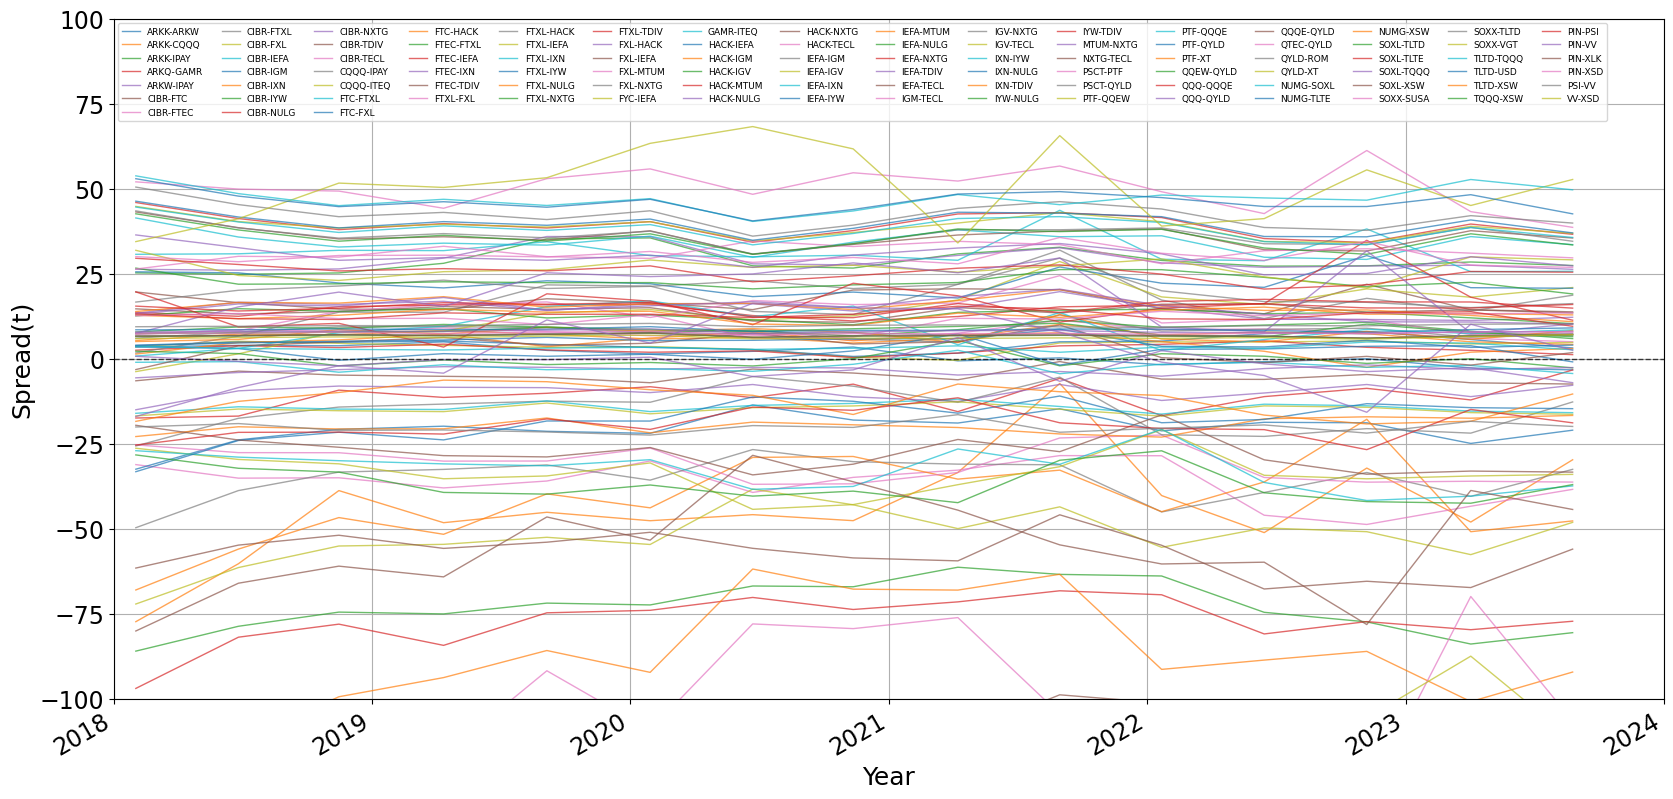

In [17]:
fig, ax = plt.subplots(figsize=(20, 10))
for i in range(len(pairs)):
    pairs[i][2]['spread'][::100].plot(
        ax=ax,
        grid=True,
        label='{}-{}'.format(pairs[i][0], pairs[i][1]),
        linewidth=1,
        alpha=0.7
    )
ax.set_ylabel('Spread(t)', size=18)
ax.set_xlabel('Year', size=18)
ax.set_xlim(('2018', '2024'))
ax.legend(fontsize=6.5, loc='upper left', ncol=16)
#ax.set_title(f'Spreads of the {len(pairs)} Selected Pairs', size=16)
#ax.set_yscale('symlog', linthresh=1)
ax.set_ylim(-100, 100)
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
plt.savefig('images/CAE_spreads.png', bbox_inches='tight', pad_inches=0.05)

## Validation Set

In [18]:
rnn_models = read_models(path=f'{current_path}/models/mlp/') 
#rnn_models

In [20]:
etf_list = pd.read_excel(f'tech_etfs.xlsx')
ticker_segment_dict = dict(zip(etf_list['Ticker'], etf_list['Description']))
ticker_segment_dict

{'ARKK': 'ARK Innovation ETF',
 'ARKQ': 'ARK Autonomous Technology & Robotics ETF',
 'ARKW': 'ARK Next Generation Internet ETF',
 'CIBR': 'First Trust NASDAQ Cybersecurity ETF',
 'CQQQ': 'Invesco China Technology ETF',
 'CWEB': 'Direxion Daily CSI China Internet Bull 2X Shares',
 'DTEC': 'ALPS Disruptive Technologies ETF',
 'FDN': 'First Trust Dow Jones Internet Index Fund',
 'FTC': 'First Trust Large Cap Growth AlphaDEX Fund',
 'FTEC': 'Fidelity MSCI Information Technology Index ETF',
 'FTXL': 'First Trust Nasdaq Semiconductor ETF',
 'FXI': 'iShares China Large-Cap ETF',
 'FXL': 'First Trust Technology AlphaDEX Fund',
 'FXP': 'ProShares UltraShort FTSE China 50',
 'FYC': 'First Trust Small Cap Growth AlphaDEX Fund',
 'GAMR': 'Wedbush ETFMG Video Game Tech ETF',
 'HACK': 'ETFMG Prime Cyber Security ETF',
 'IDLV': 'Invesco S&P International Developed Low Volatility ETF',
 'IDMO': 'Invesco S&P International Developed Momentum ETF',
 'IDX': 'VanEck Vectors Indonesia Index ETF',
 'IEFA': '

In [22]:
# model to test
n_in = 24
hidden_nodes = [[50]]
low_quantile = 0.10
high_quantile = 0.90
train_val_split = '01-01-2023'

mlp_path=(f'models/mlp/')

In [80]:
model_rnn, cumret_val, sharperatio_val,summaries_rnn, balance_summaries_rnn = \
            forecasting_trader.run_specific_model(
                                                n_in, 
                                                hidden_nodes, 
                                                pairs,
                                                path=mlp_path,
                                                train_val_split=train_val_split,
                                                low_quantile=low_quantile, 
                                                high_quantile=high_quantile, 
                                                lag=1,
                                                )

In [81]:
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(pairs))]
#performance_rnn

Annual ROI:  -2.193601922989341
34.343434343434346 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -6.632452078991177
Autocorrelation:  0.1395230831898887
Daily Sharpe Ratio -0.41230206784050744
Total number of trades:  699
Positive trades:  323
Negative trades:  376
Total Drawdown Days: 134 days
Max DD period: 3 days
Maximum drawdown of portfolio: -2.34%


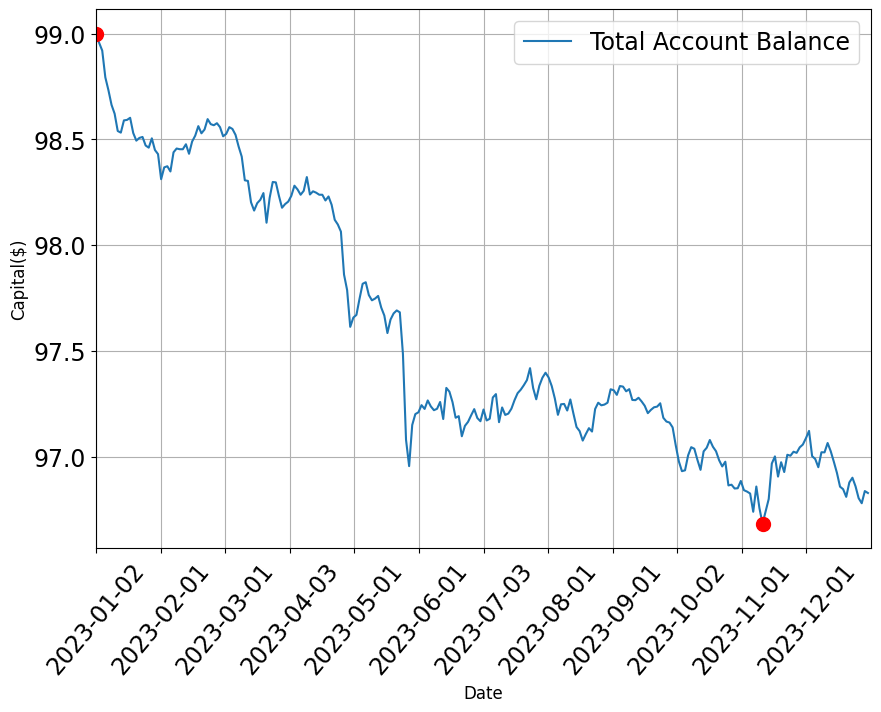

In [82]:
results, pairs_summary = trader.summarize_results(sharperatio_val,
                                                  cumret_val,
                                                  performance_rnn,
                                                  pairs, ticker_segment_dict,
                                                  n_years=1)

In [83]:
results

{'n_pairs': 99,
 'portfolio_sharpe_ratio': -0.41230206784050744,
 'avg_total_roi': -2.1936019229893446,
 'avg_annual_roi': -2.193601922989341,
 'pct_positive_trades_per_pair': 47.243762540592854,
 'pct_pairs_with_positive_results': 34.343434343434346,
 'avg_half_life': 54.80808080808081,
 'avg_hurst_exponent': 0.42056527636967966}

Training:

In [84]:
init = model_rnn[0]['predictions_train'].index[0]
true_train = [pairs[i][2]['spread'][init:train_val_split] for i in range(len(pairs))]
predictions_train = [model_rnn[i]['predictions_train'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_train, predictions_train)

11163.22E-4
820.48E-3
594.43E-3
50.25%


Validation:

In [85]:
true_val = [summaries_rnn[i]['spread(t)'] for i in range(len(pairs))]
predictions = [summaries_rnn[i]['prediction(t)'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_val, predictions)

11006.56E-4
786.30E-3
617.30E-3
49.96%


In [86]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,CIBR,First Trust NASDAQ Cybersecurity ETF,TECL,Direxion Daily Technology Bull 3X Shares,-2.621888,0.088557,66,58,0.464062,9,7,1.450532,56.250000
1,CIBR,First Trust NASDAQ Cybersecurity ETF,FTXL,First Trust Nasdaq Semiconductor ETF,-4.462021,0.000230,98,27,0.323979,7,0,1.296695,100.000000
2,FXL,First Trust Technology AlphaDEX Fund,HACK,ETFMG Prime Cyber Security ETF,-3.262330,0.016649,47,70,0.366639,20,9,1.218449,68.965517
3,QQQ,Invesco QQQ Trust,QQQE,Direxion NASDAQ-100 Equal Weighted Index Shares,-2.641148,0.084787,53,71,0.468841,6,2,0.959955,75.000000
4,FTC,First Trust Large Cap Growth AlphaDEX Fund,HACK,ETFMG Prime Cyber Security ETF,-2.948333,0.040009,51,73,0.378555,6,2,0.744718,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,IEFA,iShares Core MSCI EAFE ETF,NULG,Nuveen ESG Large-Cap Growth ETF,-3.045869,0.030827,65,62,0.491198,0,1,-5.748340,0.000000
95,CIBR,First Trust NASDAQ Cybersecurity ETF,IEFA,iShares Core MSCI EAFE ETF,-3.161719,0.022310,55,55,0.474427,0,1,-6.043688,0.000000
96,PSCT,Invesco S&P SmallCap Information Technology ETF,PTF,Invesco DWA Technology Momentum ETF,-2.631056,0.086747,46,67,0.453372,1,0,-6.131094,100.000000
97,IEFA,iShares Core MSCI EAFE ETF,IGV,iShares Expanded Tech-Software Sector ETF,-3.076244,0.028362,51,73,0.487543,0,2,-9.305009,0.000000


## **Test unrestricted**

In [29]:
model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        forecasting_trader.test_specific_model(
                n_in, 
                hidden_nodes, 
                pairs, 
                path=current_path,
                low_quantile=low_quantile, 
                high_quantile=high_quantile, 
                lag=1, 
                profitable_pairs_indices=range(len(pairs))
                )
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(pairs))]
#performance_rnn 

Annual ROI:  -3.8243749118271664
27.272727272727273 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -1.62619851833939
Autocorrelation:  -0.1538379424677849
Daily Sharpe Ratio -0.10122074097947592
Total number of trades:  1350
Positive trades:  648
Negative trades:  702
Total Drawdown Days: 132 days
Max DD period: 2 days
Maximum drawdown of portfolio: -4.70%


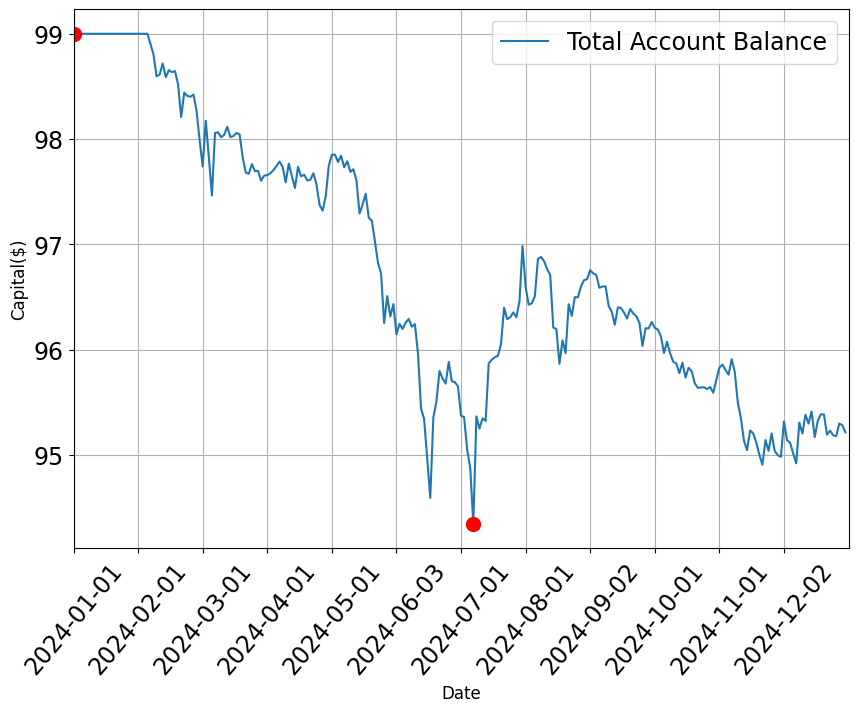

In [30]:
results, pairs_summary = trader.summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  pairs, ticker_segment_dict,
                                                  n_years=1)

In [31]:
results

{'n_pairs': 99,
 'portfolio_sharpe_ratio': -0.10122074097947592,
 'avg_total_roi': -3.8243749118271615,
 'avg_annual_roi': -3.8243749118271664,
 'pct_positive_trades_per_pair': 45.454408507293785,
 'pct_pairs_with_positive_results': 27.272727272727273,
 'avg_half_life': 54.80808080808081,
 'avg_hurst_exponent': 0.42056527636967955}

In [32]:
#pairs_summary 

Test:

In [33]:
true_test = [summaries_rnn[i]['spread(t)'] for i in range(len(pairs))]
predictions = [summaries_rnn[i]['prediction(t)'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_test, predictions)

42289.14E-4
1519.95E-3
1180.99E-3
48.55%


## **Test with active pairs on validation set**

In [87]:
pairs

[('ARKK',
  'ARKW',
  {'t_statistic': -2.5759441528439395,
   'critical_val': {'1%': -3.434827656046504,
    '5%': -2.86351758903648,
    '10%': -2.5678228503262757},
   'p_value': 0.09807174179088884,
   'coint_coef': 0.7962170095206533,
   'zero_cross': 51,
   'half_life': 81,
   'hurst_exponent': 0.3688753269178084,
   'spread': date
   2018-02-01    3.512938
   2018-02-02    3.288917
   2018-02-05    3.341412
   2018-02-06    3.442321
   2018-02-07    3.784076
                   ...   
   2023-12-22   -7.876715
   2023-12-26   -7.677953
   2023-12-27   -8.075830
   2023-12-28   -7.964927
   2023-12-29   -8.062871
   Length: 1488, dtype: float64,
   'Y_train': date
   2018-02-01    38.166034
   2018-02-02    37.276274
   2018-02-05    35.955682
   2018-02-06    36.798613
   2018-02-07    37.313737
                   ...    
   2023-12-22    53.010000
   2023-12-26    53.790000
   2023-12-27    54.260000
   2023-12-28    54.140000
   2023-12-29    52.370000
   Name: ARKK, Length: 148

In [34]:
cumret_val = np.asarray(cumret_val)
profitable_pairs_indices = np.argwhere(cumret_val > 0)
profitable_pairs = [pairs[i] for i in profitable_pairs_indices.flatten()]
model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        forecasting_trader.test_specific_model(n_in, hidden_nodes, pairs, path=current_path,
                                               low_quantile=low_quantile, high_quantile=high_quantile, lag=1, 
                                               profitable_pairs_indices=profitable_pairs_indices)
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(profitable_pairs))]
#performance_rnn

Annual ROI:  1.545706967781313
47.05882352941177 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -1.2006045049556653
Autocorrelation:  -0.043882723831632234
Daily Sharpe Ratio -0.07249386010575652
Total number of trades:  401
Positive trades:  214
Negative trades:  187
Total Drawdown Days: 117 days
Max DD period: 1 days
Maximum drawdown of portfolio: -3.42%


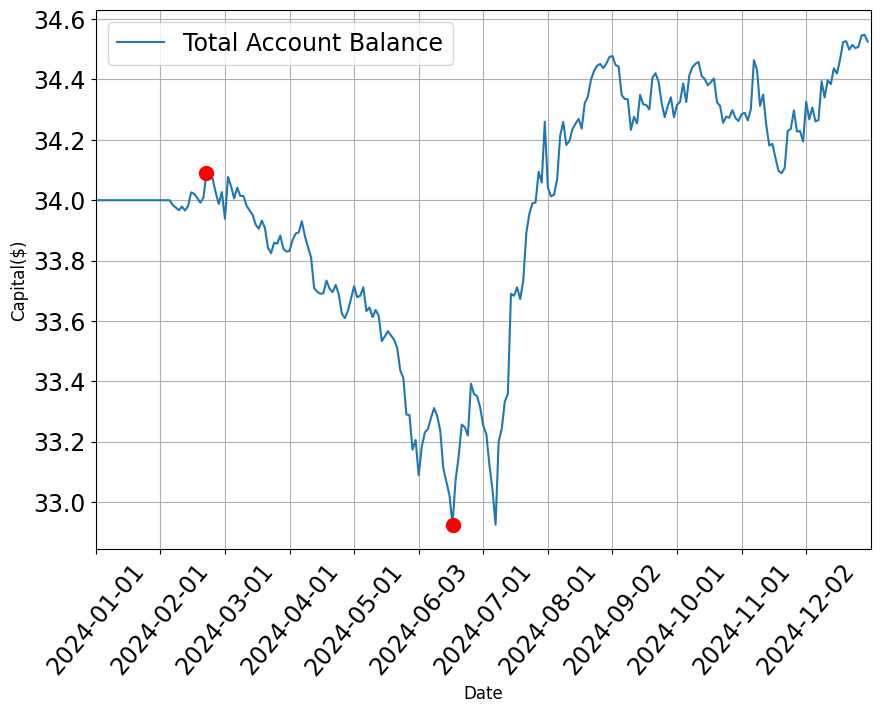

In [35]:
results, pairs_summary = trader.summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  profitable_pairs, ticker_segment_dict,
                                                  n_years=1)                                                

In [36]:
results  

{'n_pairs': 34,
 'portfolio_sharpe_ratio': -0.07249386010575652,
 'avg_total_roi': 1.5457069677813111,
 'avg_annual_roi': 1.545706967781313,
 'pct_positive_trades_per_pair': 54.42563061467248,
 'pct_pairs_with_positive_results': 47.05882352941177,
 'avg_half_life': 56.35294117647059,
 'avg_hurst_exponent': 0.4095783465928984}

In [88]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,CIBR,First Trust NASDAQ Cybersecurity ETF,TECL,Direxion Daily Technology Bull 3X Shares,-2.621888,0.088557,66,58,0.464062,9,7,1.450532,56.250000
1,CIBR,First Trust NASDAQ Cybersecurity ETF,FTXL,First Trust Nasdaq Semiconductor ETF,-4.462021,0.000230,98,27,0.323979,7,0,1.296695,100.000000
2,FXL,First Trust Technology AlphaDEX Fund,HACK,ETFMG Prime Cyber Security ETF,-3.262330,0.016649,47,70,0.366639,20,9,1.218449,68.965517
3,QQQ,Invesco QQQ Trust,QQQE,Direxion NASDAQ-100 Equal Weighted Index Shares,-2.641148,0.084787,53,71,0.468841,6,2,0.959955,75.000000
4,FTC,First Trust Large Cap Growth AlphaDEX Fund,HACK,ETFMG Prime Cyber Security ETF,-2.948333,0.040009,51,73,0.378555,6,2,0.744718,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,IEFA,iShares Core MSCI EAFE ETF,NULG,Nuveen ESG Large-Cap Growth ETF,-3.045869,0.030827,65,62,0.491198,0,1,-5.748340,0.000000
95,CIBR,First Trust NASDAQ Cybersecurity ETF,IEFA,iShares Core MSCI EAFE ETF,-3.161719,0.022310,55,55,0.474427,0,1,-6.043688,0.000000
96,PSCT,Invesco S&P SmallCap Information Technology ETF,PTF,Invesco DWA Technology Momentum ETF,-2.631056,0.086747,46,67,0.453372,1,0,-6.131094,100.000000
97,IEFA,iShares Core MSCI EAFE ETF,IGV,iShares Expanded Tech-Software Sector ETF,-3.076244,0.028362,51,73,0.487543,0,2,-9.305009,0.000000


# Test with 2 best pairs on validation set

As the PCA clustering returned 2 active pairs on MLP Trader, we will forecast the returns on the same number of pairs for sake of comparison.

In [89]:
# Top 2 profitable pairs
top_2_profitable_pairs_indices = np.argsort(cumret_val)[-20:]
top_2_pairs = [pairs[i] for i in top_2_profitable_pairs_indices.flatten()]

In [90]:
model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        forecasting_trader.test_specific_model(n_in, hidden_nodes, pairs, path=mlp_path,
                                               low_quantile=low_quantile, high_quantile=high_quantile, lag=1, 
                                               profitable_pairs_indices=top_2_profitable_pairs_indices)
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(top_2_pairs))]
performance_rnn

[(            prediction(t)  prediction(t+1)  spread(t)  predicted_change(%)  \
  date                                                                         
  2024-02-06      -9.370271                0 -10.062311             0.000000   
  2024-02-07      -9.208920                0 -10.834409             8.481065   
  2024-02-08      -9.727081                0 -10.965751            10.220473   
  2024-02-09     -10.286167                0 -11.328563             6.197331   
  2024-02-12     -10.010779                0 -10.931083            11.632402   
  ...                   ...              ...        ...                  ...   
  2024-12-24     -27.584864                0 -30.692540             7.461013   
  2024-12-26     -27.977213                0 -30.190923             8.846863   
  2024-12-27     -27.921408                0 -29.651516             7.517211   
  2024-12-30     -27.062059                0 -29.742968             8.732964   
  2024-12-31     -26.981220             

Annual ROI:  5.198646224375336
70.0 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  0.054916505826664165
Autocorrelation:  -0.03041441355196365
Daily Sharpe Ratio 0.004346332419092614
Total number of trades:  291
Positive trades:  164
Negative trades:  127
Total Drawdown Days: 107 days
Max DD period: 1 days
Maximum drawdown of portfolio: -4.51%


{'n_pairs': 20,
 'portfolio_sharpe_ratio': 0.004346332419092614,
 'avg_total_roi': 5.198646224375335,
 'avg_annual_roi': 5.198646224375336,
 'pct_positive_trades_per_pair': 63.34012448745816,
 'pct_pairs_with_positive_results': 70.0,
 'avg_half_life': 51.05,
 'avg_hurst_exponent': 0.39407473843712876}

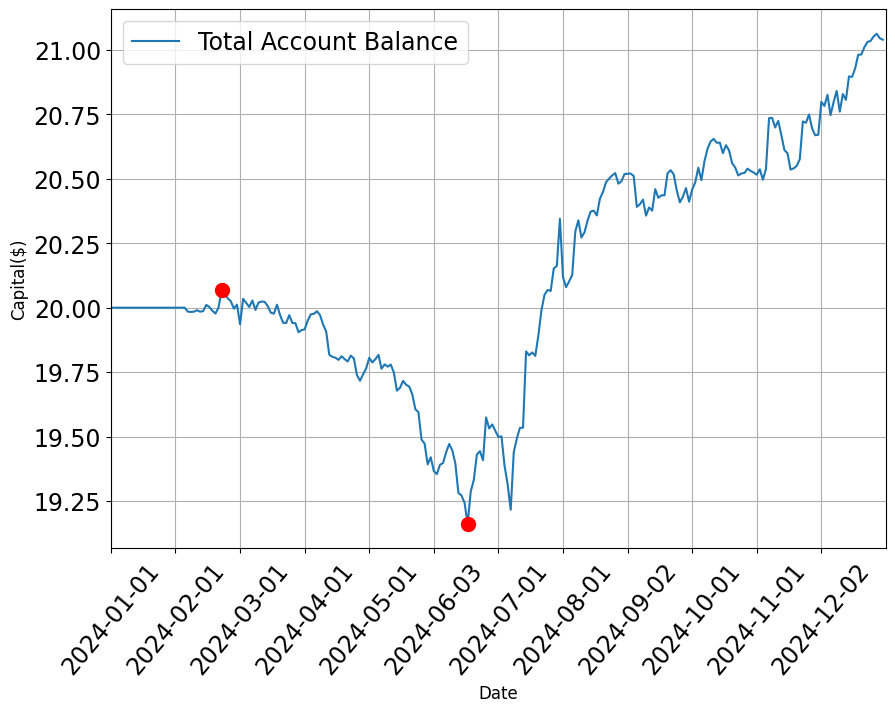

In [92]:
results, pairs_summary = trader.summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  top_2_pairs, ticker_segment_dict,
                                                  n_years=1)
results

# Sharpe ratio pairs

In [106]:
sharperatio_val = np.asarray(sharperatio_val)
sr_pairs_indices = np.argwhere(sharperatio_val > 0)
sr_pairs = [pairs[i] for i in sr_pairs_indices.flatten()]

model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        forecasting_trader.test_specific_model(n_in, hidden_nodes, pairs, path=current_path,
                                               low_quantile=low_quantile, high_quantile=high_quantile, lag=1, 
                                               profitable_pairs_indices=sr_pairs_indices)
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(sr_pairs))]

Annual ROI:  1.0446346289013864
75.0 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -1.0563893441668353
Autocorrelation:  0.07450363415371727
Daily Sharpe Ratio -0.06353098025317618
Total number of trades:  162
Positive trades:  93
Negative trades:  69
Total Drawdown Days: 114 days
Max DD period: 1 days
Maximum drawdown of portfolio: -4.83%


{'n_pairs': 12,
 'portfolio_sharpe_ratio': -0.06353098025317618,
 'avg_total_roi': 1.04463462890139,
 'avg_annual_roi': 1.0446346289013864,
 'pct_positive_trades_per_pair': 71.2741868061017,
 'pct_pairs_with_positive_results': 75.0,
 'avg_half_life': 54.333333333333336,
 'avg_hurst_exponent': 0.3909789085717801}

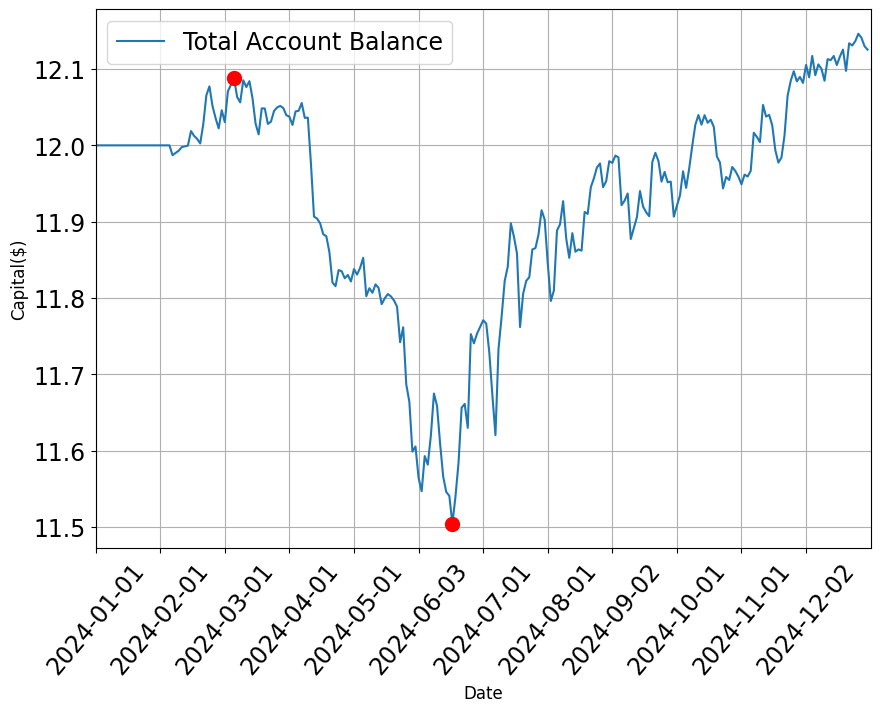

In [107]:
results, pairs_summary = trader.summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  sr_pairs, ticker_segment_dict,
                                                  n_years=1)
results

In [99]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,FTC,First Trust Large Cap Growth AlphaDEX Fund,HACK,ETFMG Prime Cyber Security ETF,-2.948333,0.040009,51,73,0.378555,6,0,1.884707,100.000000
1,CIBR,First Trust NASDAQ Cybersecurity ETF,TECL,Direxion Daily Technology Bull 3X Shares,-2.621888,0.088557,66,58,0.464062,31,16,0.114425,65.957447
2,CIBR,First Trust NASDAQ Cybersecurity ETF,FTEC,Fidelity MSCI Information Technology Index ETF,-3.164843,0.022112,90,60,0.371820,7,5,0.023636,58.333333
3,ARKK,ARK Innovation ETF,ARKW,ARK Next Generation Internet ETF,-2.575944,0.098072,51,81,0.368875,0,0,0.000000,NaN
4,CIBR,First Trust NASDAQ Cybersecurity ETF,IXN,iShares Global Tech ETF,-3.390555,0.011285,82,52,0.362141,9,9,-0.075693,50.000000
5,GAMR,Wedbush ETFMG Video Game Tech ETF,ITEQ,BlueStar Israel Technology ETF,-3.092291,0.027129,52,45,0.399279,4,0,-0.080541,100.000000
6,QQQ,Invesco QQQ Trust,QQQE,Direxion NASDAQ-100 Equal Weighted Index Shares,-2.641148,0.084787,53,71,0.468841,1,0,-0.354962,100.000000
7,CIBR,First Trust NASDAQ Cybersecurity ETF,FTXL,First Trust Nasdaq Semiconductor ETF,-4.462021,0.000230,98,27,0.323979,6,7,-0.365748,46.153846
8,CIBR,First Trust NASDAQ Cybersecurity ETF,IYW,iShares U.S. Technology ETF,-3.287700,0.015437,52,56,0.374151,17,18,-0.666595,48.571429
9,FTXL,First Trust Nasdaq Semiconductor ETF,IYW,iShares U.S. Technology ETF,-3.198691,0.020061,74,28,0.394956,4,1,-1.053401,80.000000
